# Elliptic PDE

Original QMCPy demo: [`QMCPy/demos/elliptic-pde.ipynb`](../../QMCPy/demos/elliptic-pde.ipynb)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/QMC.jl/blob/develop/demos/elliptic_pde.ipynb)

A Julia translation of the Python elliptic PDE demo.

Parity note: this Julia notebook keeps QMCPy's Sections 1-4 aligned, while the Python helper-function layout and plotting setup are replaced by Julia-native multilevel interfaces and lighter notebook infrastructure.


In [1]:
using QMC
using LinearAlgebra
using SpecialFunctions: besselk, gamma
using Printf
using Random
Random.seed!(9999)

# Plots.jl is an optional visualisation dep; cells that call plot/heatmap
# are guarded so notebooks run cleanly in headless CI environments.
const HAVE_PLOTS = Base.find_package("Plots") !== nothing
HAVE_PLOTS && @eval using Plots
if HAVE_PLOTS
    Plots.default(
        titlefont=Plots.font(9),
        plot_titlefont=Plots.font(11),
        left_margin=4Plots.mm,
        right_margin=8Plots.mm,
        top_margin=8Plots.mm,
        bottom_margin=5Plots.mm,
    )
end

We apply Monte Carlo and quasi-Monte Carlo methods to approximate the expected value of a quantity of interest derived from the solution of a one-dimensional elliptic PDE, where the diffusion coefficient is a lognormal Gaussian random field. This is often referred to as *the fruitfly problem* of uncertainty quantification.

> **Note:** This Julia notebook now follows the same four-part structure as the QMCPy demo: problem definition, single-level methods, multilevel methods, and convergence tests. The mathematical workflow is the same, but the implementation uses Julia-native `QMC.jl` interfaces instead of the Python helper-function layout from the original notebook.

## 1. Problem Definition

Let $Q$ be a quantity of interest derived from the solution $u(x, \omega)$ of the 1D elliptic PDE

$$-\frac{d}{dx}\bigg(a(x, \omega) \frac{d}{dx} u(x, \omega) \bigg) = f(x), \quad 0 \leq x \leq 1,$$
$$u(0, \cdot) = u_0, \quad u(1, \cdot) = u_1.$$

The diffusion coefficient $a(x, \omega) = \exp(b(x, \omega))$ is a lognormal Gaussian random field with Matérn covariance

$$c(x, y) = \frac{2^{1-\nu}}{\Gamma(\nu)} \left(\frac{\|x - y\|}{\lambda}\right)^\nu K_\nu\!\left(\frac{\|x - y\|}{\lambda}\right)$$

where $\lambda$ is the length scale, $\nu$ is the smoothness parameter, $\Gamma$ is the gamma function, and $K_\nu$ is the modified Bessel function of the second kind.

We begin by defining the Matérn covariance function:

In [2]:
function matern(x, y; smoothness=1, lengthscale=1)
    r = abs.(x .- y) ./ lengthscale
    prefactor = 2.0^(1 - smoothness) / gamma(smoothness)
    cov = prefactor .* (r .^ smoothness) .* besselk.(smoothness, r)
    # besselk diverges at r=0; covariance at distance 0 is 1
    cov[r .== 0] .= 1.0
    return cov
end

function get_covariance_matrix(pts; smoothness=1, lengthscale=1)
    X = pts' .* ones(length(pts))
    Y = ones(length(pts))' .* pts
    return matern(X, Y; smoothness, lengthscale)
end

get_covariance_matrix (generic function with 1 method)

Let's look at the covariance matrix for `n = 25` equidistant points in [0, 1]:

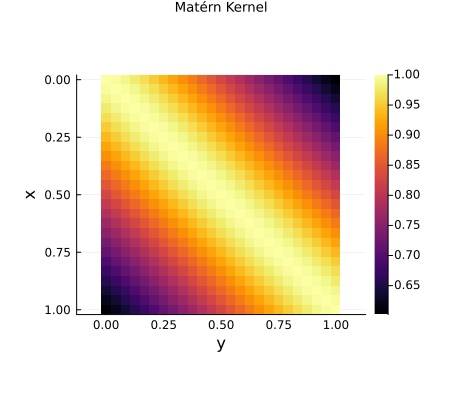

In [3]:
if HAVE_PLOTS
    let n = 25, pts = collect(range(0, 1, length=n))
        heatmap(pts, pts, get_covariance_matrix(pts);
            xlabel="y", ylabel="x", title="Matérn Kernel",
            yflip=true, aspect_ratio=:equal, size=(450, 400))
    end
end

### Karhunen–Loève Expansion

A Gaussian random field $b(x, \omega)$ with covariance matrix $C = V W V^T$ can be sampled as

$$\boldsymbol{b} = V W^{1/2} \boldsymbol{x}$$

where $\boldsymbol{x} \sim \mathcal{N}(0, I)$. We compute the eigenvalue decomposition:

In [4]:
function get_eigenpairs(n; smoothness=1, lengthscale=1)
    h = 1 / (n - 1)
    pts = collect(range(h/2, 1 - h/2, length=n - 1))
    cov = get_covariance_matrix(pts; smoothness, lengthscale)
    F = eigen(Symmetric(cov))
    # Sort descending by eigenvalue (eigen returns ascending)
    idx = sortperm(F.values, rev=true)
    w = F.values[idx]
    v = F.vectors[:, idx]
    # Ensure consistent eigenvector orientation (first component positive)
    for col in axes(v, 2)
        if v[1, col] < 0
            v[:, col] .*= -1
        end
    end
    return pts, w, v
end

get_eigenpairs (generic function with 1 method)

Next, we plot the first few eigenfunctions for different grid sizes:

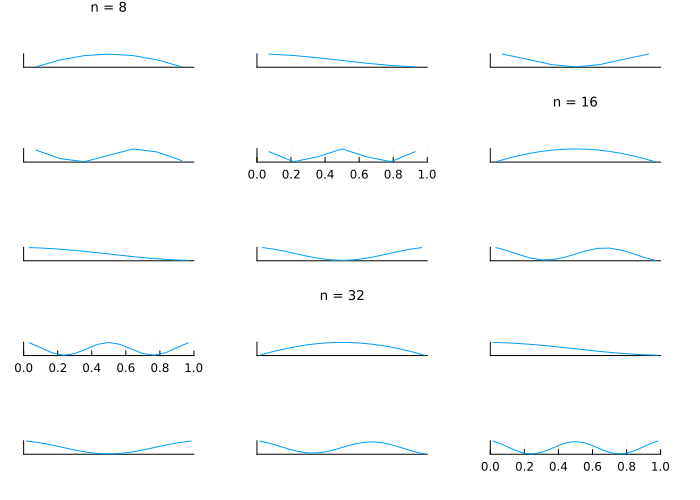

In [5]:
if HAVE_PLOTS
    let ns = [8, 16, 32], m = 5
        local plots_arr = []
        for (j, k) in enumerate(ns)
            local pts_k, w_k, v_k = get_eigenpairs(k)
            for i in 1:m
                local p = plot(pts_k, v_k[:, i]; xlims=(0, 1), legend=false, yticks=[])
                if i == 1
                    title!(p, "n = $k")
                end
                if i < m
                    plot!(p; xticks=[])
                end
                push!(plots_arr, p)
            end
        end
        plot(plots_arr...; layout=(5, 3), size=(700, 500))
    end
end

With the eigendecomposition, we can sample the Gaussian random field as $\boldsymbol{b} = V_{:,1:m}\, \mathrm{diag}(\sqrt{w_{1:m}})\, \boldsymbol{y}$:

In [6]:
function kl_evaluate(w, v; y=nothing)
    if isnothing(y)
        y = randn(length(w) - 1)
    end
    m = length(y)
    return v[:, 1:m] * (sqrt.(w[1:m]) .* y)
end

kl_evaluate (generic function with 1 method)

Let's plot a few realizations of the Gaussian random field $b(x, \omega)$:

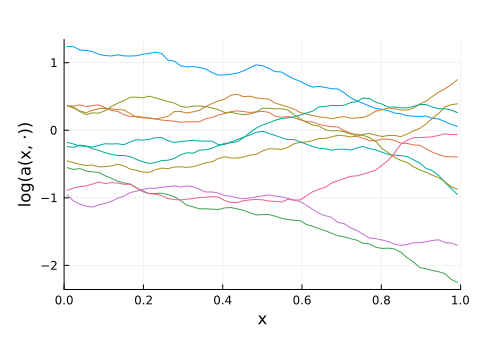

In [7]:
if HAVE_PLOTS
    let n = 64
        local pts_gf, w_gf, v_gf = get_eigenpairs(n)
        local p = plot(; xlabel="x", ylabel="log(a(x, ⋅))", xlims=(0, 1), size=(500, 350))
        for _ in 1:10
            plot!(p, pts_gf, kl_evaluate(w_gf, v_gf); label=false)
        end
        p
    end
end

### PDE Solver

Using a finite-difference discretization, the PDE reduces to a tridiagonal system solvable in $O(n)$ time via the Thomas algorithm. We assume $f(x) = 1$ and Dirichlet boundary conditions $u(0) = u(1) = 0$.

In [8]:
function thomas(a, b, c, d)
    n = length(b)
    b = copy(b)
    d = copy(d)
    x = zeros(n)
    for i in 2:n
        local w = a[i-1] / b[i-1]
        b[i] -= w * c[i-1]
        d[i] -= w * d[i-1]
    end
    x[n] = d[n] / b[n]
    for i in (n-1):-1:1
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    end
    return x
end

function pde_solve(a)
    n = length(a)
    rhs = fill(1.0 / n^2, n - 1)
    x = thomas(-a[2:n-1], a[1:n-1] .+ a[2:n], -a[2:n-1], rhs)
    return [0.0; x; 0.0]
end

pde_solve (generic function with 1 method)

Let's compute and plot several PDE solutions $u(x, \omega)$:

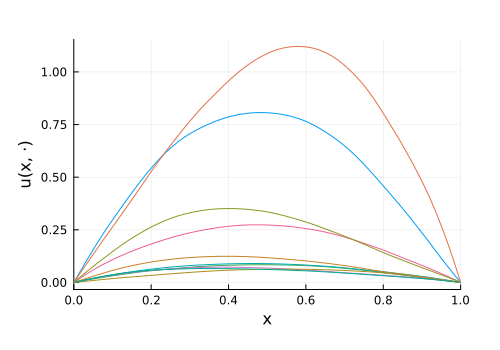

In [9]:
if HAVE_PLOTS
    let n = 64
        local _, w_pde, v_pde = get_eigenpairs(n)
        local xgrid = range(0, 1, length=n)
        local p = plot(; xlabel="x", ylabel="u(x, ⋅)", xlims=(0, 1), size=(500, 350))
        for _ in 1:10
            local a = exp.(kl_evaluate(w_pde, v_pde))
            local u = pde_solve(a)
            plot!(p, xgrid, u; label=false)
        end
        p
    end
end

### Coarse vs. Fine Grid Comparison

Multilevel methods rely on correlated coarse and fine grid solutions. Since we use the KL expansion, correlated samples are obtained by truncating the same random vector. Here we illustrate with fine grid $n_f = 16$ and coarse grid $n_c = 8$:

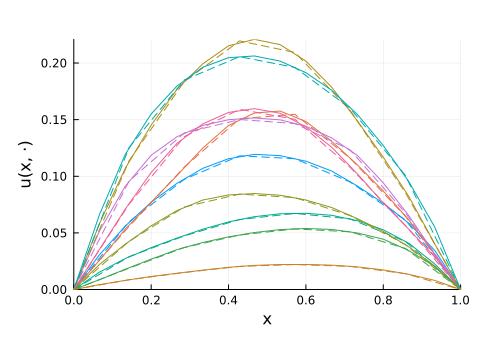

In [10]:
if HAVE_PLOTS
    let nf = 16, nc = 8
        local _, wf, vf = get_eigenpairs(nf)
        local _, wc, vc = get_eigenpairs(nc)
        local xf = range(0, 1, length=nf)
        local xc = range(0, 1, length=nc)
        local p = plot(; xlabel="x", ylabel="u(x, ⋅)", xlims=(0, 1), ylims=(0, Inf), size=(500, 350))
        local colors = palette(:default)
        for k in 1:10
            local yf = randn(nf - 1)
            local af = exp.(kl_evaluate(wf, vf; y=yf))
            local uf = pde_solve(af)
            plot!(p, xf, uf; color=colors[mod1(k, length(colors))], label=false)
            local yc = yf[1:nc-1]
            local ac = exp.(kl_evaluate(wc, vc; y=yc))
            local uc = pde_solve(ac)
            plot!(p, xc, uc; color=colors[mod1(k, length(colors))], linestyle=:dash, label=false)
        end
        p
    end
end

## 2. Single-Level Methods

We compute $\mathbb{E}[Q]$ where $Q = u(1/2, \cdot)$ is the PDE solution at the midpoint. We wrap the PDE evaluator in a `CustomFun` integrand and apply `CubMCCLT` (Monte Carlo) and `CubQMCLatticeG` (quasi-Monte Carlo with replicated lattice rules).

In [11]:
function make_elliptic_pde(dd; smoothness=1, lengthscale=1)
    dim = dd.dimension
    n_grid = dim + 1
    _, w, v = get_eigenpairs(n_grid; smoothness, lengthscale)
    tm = Gaussian(dd)
    g = x -> begin
        nrows = size(x, 1)
        out = zeros(nrows)
        for i in 1:nrows
            local a = exp.(kl_evaluate(w, v; y=x[i, :]))
            local u = pde_solve(a)
            out[i] = u[div(length(u), 2) + 1]
        end
        out
    end
    CustomFun(tm, g)
end

function test_method(dd, sc_type; abs_tol=5e-3, kwargs...)
    f = make_elliptic_pde(dd)
    sc = sc_type(f; abs_tol=abs_tol, kwargs...)
    local result
    t = @elapsed begin
        result = integrate(sc)
    end
    println(result)
    @printf("
Computed solution %.3f in %.2f s
", result.solution, t)
    return result
end

test_method (generic function with 1 method)

### Monte Carlo

The MC estimator is the sample average $\mathcal{Q}_N^{\mathrm{MC}} = \frac{1}{N}\sum_{n=0}^{N-1} Q^{(n)}$. We increase $N$ until the error criterion is satisfied. The solution should be $\approx 0.189$.

In [12]:
# MC with 32 stochastic dimensions
test_method(IIDStdUniform(32), CubMCCLT)

QMCResult(solution=1.883106e-01, n_total=20241

, error_bound=4.91e-03)

Computed solution 0.188 in 0.11 s


QMCResult(solution=1.883106e-01, n_total=20241, error_bound=4.91e-03)

### Quasi-Monte Carlo

The QMC estimator uses low-discrepancy lattice points instead of random points. We run $K = 8$ independent replications to estimate the error:

In [13]:
# QMC with replicated lattice (32 dimensions, 8 replications)
test_method(Lattice(32; replications=8), CubQMCLatticeG; n_init=32)

QMCResult(solution=1.517085e+00, n_total=4096

, error_bound=4.44e-03)

Computed solution 1.517 in 0.27 s


QMCResult(solution=1.517085e+00, n_total=4096, error_bound=4.44e-03)

## 3. Multilevel Methods

The multilevel Monte Carlo (MLMC) and multilevel quasi-Monte Carlo (MLQMC) methods use the telescoping sum

$$\mathbb{E}[Q_L] = \mathbb{E}[Q_0] + \sum_{\ell=1}^{L} \mathbb{E}[Q_\ell - Q_{\ell-1}]$$

to efficiently approximate $\mathbb{E}[Q]$. Each term $\mathbb{E}[Q_\ell - Q_{\ell-1}]$ is estimated independently using correlated coarse/fine grid solutions at level $\ell$. The variance of $Q_\ell - Q_{\ell-1}$ decreases with $\ell$, so fewer samples are needed at finer levels.

We define a multilevel integrand that implements the `AbstractMLIntegrand` interface:

In [14]:
struct MLEllipticPDE <: AbstractMLIntegrand
    true_measure::AbstractTrueMeasure
    dimension::Int
    smoothness::Int
    lengthscale::Int
    nb_of_levels::Int
    n_grid::Vector{Int}          # grid size at each level
    eigenpairs::Dict{Int, Tuple}  # level => (w, v)
end

function MLEllipticPDE(dd::AbstractDiscreteDistribution;
                        smoothness=1, lengthscale=1)
    dim = dd.dimension
    nb_of_levels = Int(log2(dim))
    n_grid = [2^(l+1) + 1 for l in 0:nb_of_levels-1]
    eigenpairs = Dict{Int, Tuple}()
    for l in 0:nb_of_levels-1
        _, w, v = get_eigenpairs(n_grid[l+1]; smoothness, lengthscale)
        eigenpairs[l] = (w, v)
    end
    tm = Gaussian(dd)
    MLEllipticPDE(tm, dim, smoothness, lengthscale, nb_of_levels, n_grid, eigenpairs)
end

function QMC.dimension_at_level(f::MLEllipticPDE, level::Int)
    return f.n_grid[level+1] - 1
end

function QMC.cost_at_level(f::MLEllipticPDE, level::Int)
    return Float64(f.n_grid[level+1])
end

function QMC.ml_evaluate(f::MLEllipticPDE, x::AbstractMatrix, level::Int)
    n = size(x, 1)
    Qf = zeros(n)
    Qc = zeros(n)
    wf, vf = f.eigenpairs[level]
    nf = f.n_grid[level+1]
    for i in 1:n
        local af = exp.(kl_evaluate(wf, vf; y=x[i, 1:nf-1]))
        local uf = pde_solve(af)
        Qf[i] = uf[div(length(uf), 2) + 1]
    end
    if level > 0
        wc, vc = f.eigenpairs[level - 1]
        nc = f.n_grid[level]
        for i in 1:n
            local ac = exp.(kl_evaluate(wc, vc; y=x[i, 1:nc-1]))
            local uc = pde_solve(ac)
            Qc[i] = uc[div(length(uc), 2) + 1]
        end
    end
    return Qc, Qf
end

In [15]:
function test_ml_method(dd, sc_type; abs_tol=5e-3, kwargs...)
    f = MLEllipticPDE(dd)
    sc = sc_type(f; abs_tol=abs_tol, kwargs...)
    local result
    t = @elapsed begin
        result = integrate(sc)
    end
    println(result)
    @printf("\nComputed solution %.3f in %.2f s\n", result.solution, t)
    @printf("Levels: %d, Total samples: %d\n", result.data[:levels], result.data[:n_total])
    return result
end

test_ml_method (generic function with 1 method)

### 3.1 Multilevel Monte Carlo

We apply `CubMLMC` (Giles, 2008) to the elliptic PDE problem. The algorithm adaptively allocates samples across levels to minimize total cost for a given error tolerance.

In [16]:
# MLMC with 32 stochastic dimensions
test_ml_method(IIDStdUniform(32), CubMLMC; abs_tol=5e-3)

QMCResult(solution=1.907471e-01, n_total=49081

)

Computed solution 0.191 in 0.12 s
Levels: 3, Total samples: 49081


QMCResult(solution=1.907471e-01, n_total=49081)

### 3.2 Continuation Multilevel Monte Carlo

`CubMLMCCont` runs MLMC at progressively tighter tolerances, reusing samples from coarser stages. This improves the estimation of the convergence rates $\alpha$, $\beta$, $\gamma$ before the final tolerance is reached.

In [17]:
# Continuation MLMC
test_ml_method(IIDStdUniform(32), CubMLMCCont; abs_tol=5e-3, n_tols=10)

QMCResult(solution=1.914897e-01, n_total=17851

)

Computed solution 0.191 in 0.01 s
Levels: 3, Total samples: 17851


QMCResult(solution=1.914897e-01, n_total=17851)

### 3.3 Continuation Multilevel Quasi-Monte Carlo

Now we switch to quasi-Monte Carlo by using a replicated lattice rule. `CubMLQMCCont` combines the multilevel telescoping sum with QMC variance reduction, requiring replicated sequences to estimate the QMC error.

In [18]:
# Continuation MLQMC with replicated lattice
test_ml_method(Lattice(32; replications=8), CubMLQMCCont; abs_tol=5e-3, n_init=32)

QMCResult(solution=1.909460e-01, n_total=66304

)

Computed solution 0.191 in 0.13 s
Levels: 3, Total samples: 66304


QMCResult(solution=1.909460e-01, n_total=66304)

## 4. Convergence Tests

We run convergence tests to compare the cost of MC, QMC, MLMC, and MLQMC as a function of the error tolerance. For each method, we solve the problem at several tolerance levels and record the total equivalent cost.

In [19]:
function convergence_test(; smoothness=1, lengthscale=1)
    tols = [0.1, 0.05, 0.02, 0.01]

    cost_mc = Float64[]
    cost_qmc = Float64[]
    cost_mlmc = Float64[]
    cost_mlqmc = Float64[]

    for tol in tols
        # MC (single-level)
        dd_mc = IIDStdUniform(32)
        f_mc = make_elliptic_pde(dd_mc; smoothness, lengthscale)
        sc_mc = CubMCCLT(f_mc; abs_tol=tol, n_init=8192)
        r_mc = integrate(sc_mc)
        push!(cost_mc, Float64(r_mc.data[:n]))

        # QMC (single-level)
        dd_qmc = Lattice(32; replications=8)
        f_qmc = make_elliptic_pde(dd_qmc; smoothness, lengthscale)
        sc_qmc = CubQMCLatticeG(f_qmc; abs_tol=tol, n_init=32)
        r_qmc = integrate(sc_qmc)
        push!(cost_qmc, Float64(r_qmc.data[:n] * r_qmc.data[:n_reps]))

        # MLMC
        dd_mlmc = IIDStdUniform(32)
        f_mlmc = MLEllipticPDE(dd_mlmc; smoothness, lengthscale)
        sc_mlmc = CubMLMCCont(f_mlmc; abs_tol=tol, n_tols=5)
        r_mlmc = integrate(sc_mlmc)
        # Compute equivalent cost at finest level
        n_lvl = r_mlmc.data[:n_level]
        L = length(n_lvl)
        cost_per = [Float64(2^l + (l > 0 ? 2^(l-1) : 0)) for l in 0:L-1]
        cost_per ./= cost_per[end]
        push!(cost_mlmc, sum(n_lvl .* cost_per))

        # MLQMC
        dd_mlqmc = Lattice(32; replications=8)
        f_mlqmc = MLEllipticPDE(dd_mlqmc; smoothness, lengthscale)
        sc_mlqmc = CubMLQMCCont(f_mlqmc; abs_tol=tol, n_init=32, n_tols=5)
        r_mlqmc = integrate(sc_mlqmc)
        n_lvl_q = r_mlqmc.data[:n_level]
        L_q = length(n_lvl_q)
        cost_per_q = [Float64(2^l + (l > 0 ? 2^(l-1) : 0)) for l in 0:L_q-1]
        cost_per_q ./= cost_per_q[end]
        push!(cost_mlqmc, sum(n_lvl_q .* cost_per_q))
    end

    return tols, cost_mc, cost_qmc, cost_mlmc, cost_mlqmc
end

convergence_test (generic function with 1 method)

In [20]:
tols, cost_mc, cost_qmc, cost_mlmc, cost_mlqmc = convergence_test()

([0.1, 0.05, 0.02, 0.01], [16384.0, 16384.0, 16384.0, 16384.0], [32.0, 32.0, 512.0, 2048.0], [426.66666666666663, 426.66666666666663, 513.3333333333333, 1265.1666666666665], [53.33333333333333, 58.666666666666664, 133.33333333333331, 133.33333333333331])

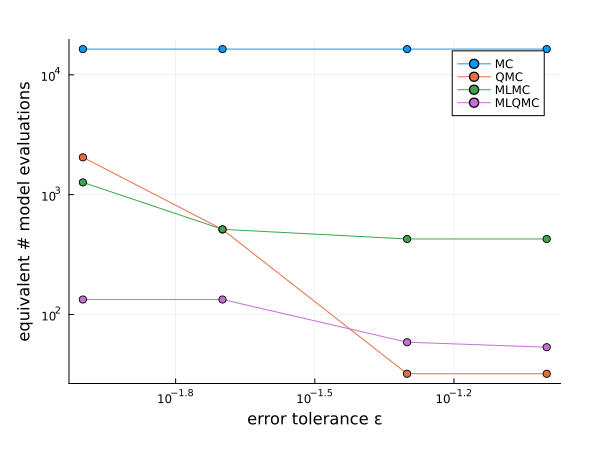

In [21]:
if HAVE_PLOTS
    plot(tols, cost_mc; marker=:circle, label="MC", xscale=:log10, yscale=:log10,
        xlabel="error tolerance ε", ylabel="equivalent # model evaluations",
        legend=:topright, size=(600, 450))
    plot!(tols, cost_qmc; marker=:circle, label="QMC")
    plot!(tols, cost_mlmc; marker=:circle, label="MLMC")
    plot!(tols, cost_mlqmc; marker=:circle, label="MLQMC")
end

The multilevel methods (MLMC and MLQMC) achieve the same accuracy with significantly fewer equivalent model evaluations at the finest level compared to their single-level counterparts. The quasi-Monte Carlo variants (QMC and MLQMC) further improve efficiency by exploiting the smoothness of the integrand.